### Stream Flix SVD Recommender

This notebook processes data taken from people who rated a variety of music and performs data anaylsis as requested by StramFlix


#### 1. Data Analysis

Do some preliminary analysis to get a sense of what the data looks like

1. DESCRIPTION OF RATING VALUES
--------------------------------------------------
count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

2. RATINGS PER USER
--------------------------------------------------
Min ratings per user:     20
Median ratings per user:  70.5
Max ratings per user:     2698
Mean ratings per user:    165.30
Total unique users:       610

3. RATINGS PER MOVIE
--------------------------------------------------
Min ratings per movie:     1
Median ratings per movie:  3.0
Max ratings per movie:     329
Mean ratings per movie:    10.37
Total unique movies:       9724

4. TOP 10 MOVIES
--------------------------------------------------
1. The Age of Innocence (1993): 329 ratings
2. I Love Trouble (1994): 317 ratings
3. Virtuosity (1995): 307 ratings
4. Cemetery Man (Dellamorte Dellamore) (1994): 279 ratings
5. Te

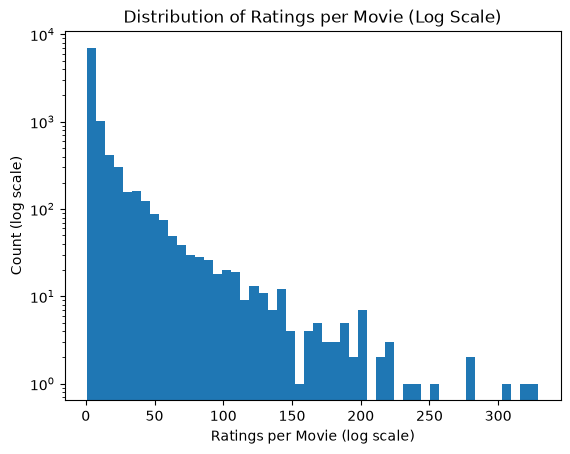

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the csv file to look at the people readings
df = pd.read_csv('data/ratings.csv')

print("1. DESCRIPTION OF RATING VALUES")
print("-" * 50)
print(df['rating'].describe())

print("\n2. RATINGS PER USER")
print("-" * 50)

# Group by ratings per user
ratings_per_user = df.groupby("userId").size()
print(f"Min ratings per user:     {ratings_per_user.min()}")
print(f"Median ratings per user:  {ratings_per_user.median()}")
print(f"Max ratings per user:     {ratings_per_user.max()}")
print(f"Mean ratings per user:    {ratings_per_user.mean():.2f}")
print(f"Total unique users:       {df["userId"].nunique()}")

print("\n3. RATINGS PER MOVIE")
print("-" * 50)

# Group by ratings per movie
ratings_per_movie = df.groupby("movieId").size()
print(f"Min ratings per movie:     {ratings_per_movie.min()}")
print(f"Median ratings per movie:  {ratings_per_movie.median():.1f}")
print(f"Max ratings per movie:     {ratings_per_movie.max()}")
print(f"Mean ratings per movie:    {ratings_per_movie.mean():.2f}")
print(f"Total unique movies:       {df["movieId"].nunique()}")

print("\n4. TOP 10 MOVIES")
print("-" * 50)

# Get the top 10 highest rated movies
top_films = ratings_per_movie.nlargest(10)

# Load what movie the ID corresponds to
movies = pd.read_csv('data/movies.csv')
for i, (id, qty) in enumerate(top_films.items(), 1):
    movie_name = movies.loc[id, 'title']
    if ", The" in movie_name:
        movie_name = "The " + movie_name.replace(", The", "")
    print(f"{i}. {movie_name}: {qty} ratings")

# Display ratings per film on a log scale
print("\n5. RATING HISTOGRAM")
print("-" * 50)

plt.hist(ratings_per_movie, bins=50)
plt.yscale('log')
plt.title('Distribution of Ratings per Movie (Log Scale)')
plt.xlabel('Ratings per Movie (log scale)')
plt.ylabel('Count (log scale)')
plt.show()


The shape of this data implies that the data is very sparse, as there are 610 unique users and 9,724 unique movies, which means that there should be 5,931,640 ratings. However, in this datset, there are only 100,836 which means that the ratings matrix is 98.6% empty. This implies that typical recommendation metrics won't work here, as it is impossible to compare most users and most movies.

The users that will be the harderst to predict are those who have not rated many movies. This could be because the user is new, the user only watches specific movies, or the user just doesn't like rating movies. The hardest movies to predict will be those that have not been watched by many people, which is the vast majority of movies. Only a few very popular movies have many ratings.

### 2. Baselines

In [ ]:
from sklearn.model_selection import train_test_split
import math

# Split the data into test & train data
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Create evaluation function
def eval_dataset(df, predictor):
    df_len = len(df)
    mse = 0

    for idx, row in df.iterrows():
        prediction = predictor(row['userId'], row['movieId'])
        mse = mse + ((prediction - row['rating']) ** 2 / df_len)

    return math.sqrt(mse)

# GLOBAL MEAN
global_mean = train_df['rating'].mean()

# EVALUATE ON TEST DATASET
mse = 0
rmse = eval_dataset(test_df, lambda *args: global_mean)
print(f"RMSE For Global Mean: {rmse:.3f}")

# USER MEAN


RMSE For Global Mean: 1.049
